# Social complexity vs scientists and artists
Correlates the Seshat social complexity index of each polity with the number of Cultura scientists and artists active during it, for the Chinese world and four other cultural worlds.

In [1]:
import json
import random
import tempfile

import duckdb
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import polars as pl
from scipy import stats

from style import *

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

CULTURA_DB_PATH = '../data/cultura/humans_clean_v2.duckdb'
SESHAT_DB_PATH = '../data/seshat/seshat.duckdb'
CLIOPATRIA_PATH = '../data/cliopatria_data/cliopatria_V2/cliopatria_polities_only_v3.geojson'

WORLD = 'Chinese world'
OTHER_WORLDS = ['Muslim world', 'India', 'Japan', 'Greek world']
YEARS_PER_CENTURY = 100

COLORS = {
    'complexity': DARK_BLUE,
    'scientists': GREEN,
    'artists':    ORANGE,
    'neutral':    MUTED_TEXT,
}

pl.Config.set_tbl_rows(40)
apply_style()

## External data
- **Seshat Equinox 2020** (`data/seshat/seshat.duckdb`, table `seshat_information`), built by `scripts/seshat_to_db/`.
- **Cliopatria v3** (`cliopatria_polities_only_v3.geojson`), for its `SeshatID` column only.

## Complexity characteristics

The nine complexity characteristics of Turchin et al. (2018), *Quantitative historical analysis uncovers a single dimension of complexity that structures global variation in human social organization*, PNAS. Each one is built from Equinox variables of `seshat_information`.

In [2]:
COMPLEXITY_CHARACTERISTICS = {
    'population':     ['polity_population'],
    'territory':      ['polity_territory'],
    'capital':        ['population_of_the_largest_settlement'],
    'hierarchy':      ['administrative_levels', 'military_levels', 'religious_levels', 'settlement_hierarchy'],
    'government':     ['professional_military_officers', 'professional_soldiers', 'professional_priesthood',
                       'full_time_bureaucrats', 'examination_system', 'merit_promotion',
                       'specialized_government_buildings', 'formal_legal_code', 'judges', 'courts',
                       'professional_lawyers'],
    'infrastructure': ['irrigation_systems', 'drinking_water_supply_systems', 'markets', 'food_storage_sites',
                       'roads', 'bridges', 'canals', 'ports', 'mines_or_quarries'],
    'information':    ['mnemonic_devices', 'nonwritten_records', 'written_records', 'script',
                       'non_phonetic_writing', 'phonetic_alphabetic_writing'],
    'texts':          ['lists_tables_and_classifications', 'calendar', 'sacred_texts', 'religious_literature',
                       'practical_literature', 'history', 'philosophy', 'scientific_literature', 'fiction'],
    'money':          ['articles', 'tokens', 'precious_metals', 'foreign_coins', 'indigenous_coins',
                       'paper_currency'],
}
LOG_SCALE = {'population', 'territory', 'capital'}
NUMERIC = LOG_SCALE | {'hierarchy'}
PRESENCE = {'present': 1.0, 'inferred present': 1.0, 'absent': 0.0, 'inferred absent': 0.0}
VARIABLES = sorted({v for vs in COMPLEXITY_CHARACTERISTICS.values() for v in vs})
print(f'{len(COMPLEXITY_CHARACTERISTICS)} characteristics from {len(VARIABLES)} Equinox variables')

9 characteristics from 48 Equinox variables


## Load data

### Seshat — Equinox values and polity years

In [3]:
seshat_con = duckdb.connect(SESHAT_DB_PATH, read_only=True)

seshat_values = seshat_con.execute(f'''
    SELECT  seshat_polity.polity_old_id    AS seshat_id,
            seshat_polity.polity_new_id    AS seshat_new_id,
            seshat_polity.polity_long_name AS seshat_name,
            seshat_polity.start_year       AS start_year,
            seshat_polity.end_year         AS end_year,
            {', '.join(VARIABLES)}
    FROM    seshat_information
''').pl()

seshat_con.close()
assert seshat_values['seshat_id'].is_unique().all()
print('shape:', seshat_values.shape)
seshat_values.select('seshat_id', 'seshat_name', 'start_year', 'end_year', 'polity_population').head()

shape: (373, 53)


seshat_id,seshat_name,start_year,end_year,polity_population
str,str,i64,i64,list[struct[7]]
"""AfDurrn""","""Durrani Empire""",1747,1826,[]
"""AfGhurd""","""Ghur Principality""",1025,1215,[]
"""AfGrBct""","""Greco-Bactrian Kingdom""",-256,-125,"[{""1500000"",""2000000"",""200BCE"",null,""simple"",""range"",null}]"
"""AfHepht""","""Hephthalite Empire""",408,561,"[{""26500000"",null,""500CE"",null,""simple"",""simple"",null}]"
"""AfKidar""","""Kidarite Kingdom""",388,477,"[{""1000000"",""1500000"",null,null,""simple"",""range"",null}]"


### Cliopatria — Seshat id carried by each polity

In [4]:
features = json.load(open(CLIOPATRIA_PATH))['features']
cliopatria_seshat = (
    pl.DataFrame([{'cliopatria_name': f['properties']['Name'], 'seshat_new_id': f['properties'].get('SeshatID') or ''}
                  for f in features])
    .with_columns(pl.col('seshat_new_id').str.split(';'))
    .explode('seshat_new_id')
    .with_columns(pl.col('seshat_new_id').str.strip_chars())
    .filter(pl.col('seshat_new_id') != '')
    .unique()
)
print('features:', len(features), '| distinct (polity, Seshat id) pairs:', cliopatria_seshat.height)
cliopatria_seshat.head()

features: 13755 | distinct (polity, Seshat id) pairs: 1011


cliopatria_name,seshat_new_id
str,str
"""(Kingdom of France)""","""fr_valois_k_1"""
"""County of Armagnac""","""fr_valois_k_1"""
"""Oyo Empire""","""ni_oyo_emp_2"""
"""Denmark-Norway""","""dk_denmark_norway"""
"""Chauhan Dynasty""","""in_chauhana_dyn"""


### Cultura — polity worlds and scientists / artists with their peak-productivity window

In [5]:
cultura_con = duckdb.connect(CULTURA_DB_PATH, read_only=True)
cultura_con.sql(f"SET memory_limit='4GB'; SET threads=6; SET temp_directory='{tempfile.mkdtemp()}';")

cultura_worlds = cultura_con.execute('''
    SELECT name AS cliopatria_name, unnest(world) AS world
    FROM   polity
''').pl()

creators = cultura_con.execute('''
    WITH assigned AS (
        SELECT  entity.qid                   AS qid,
                peak_productivity.start_year AS peak_start,
                peak_productivity.end_year   AS peak_end,
                unnest(polity)               AS assignment
        FROM    individual_enriched
    )
    SELECT  assigned.qid,
            assignment.polity.name AS cliopatria_name,
            assigned.peak_start,
            assigned.peak_end,
            individual.is_scientist,
            individual.is_artist
    FROM    assigned
    JOIN    individual ON individual.entity.qid = assigned.qid
    WHERE   (individual.is_scientist OR individual.is_artist)
      AND   assigned.peak_start IS NOT NULL
''').pl()

cultura_con.close()
print('polity-world pairs:', cultura_worlds.height)
print('scientist/artist x polity rows:', creators.height, '| individuals:', creators['qid'].n_unique())
creators.head()

polity-world pairs: 126
scientist/artist x polity rows: 2658018 | individuals: 1851643


qid,cliopatria_name,peak_start,peak_end,is_scientist,is_artist
str,str,i64,i64,bool,bool
"""Q11868773""","""Republic of Finland""",1933,1940,false,true
"""Q11868776""","""Russian Empire""",1884,1895,false,true
"""Q11868777""","""Russian Empire""",1901,1925,false,true
"""Q11868777""","""Republic of Finland""",1901,1925,false,true
"""Q11868777""","""Russian Republic""",1901,1925,false,true


## Preprocessing

### 1. Social complexity index (SPC1)

Each Equinox value is read as follows:
- **Numbers**: the midpoint of a range, averaged over every coded value (dated periods, uncertain or disputed alternatives).
- **Presence codes**: `present` / `inferred present` = 1, `absent` / `inferred absent` = 0, and unknown codes are dropped.
- **Money**: the most advanced form present, on a 1–6 scale (articles, tokens, precious metals, foreign coins, indigenous coins, paper currency), as in Turchin et al.

A characteristic is the mean of its variables. Population, territory and capital size are taken in log10.

In [6]:
def as_number(text):
    try:
        return float(text)
    except (TypeError, ValueError):
        return None


def numeric_value(values):
    points = []
    for v in values:
        bounds = [b for b in (as_number(v['value_from']), as_number(v['value_to'])) if b is not None]
        if bounds:
            points.append(np.mean(bounds))
    return float(np.mean(points)) if points else np.nan


def presence_value(values):
    codes = [PRESENCE[v['value_from']] for v in values if v['value_from'] in PRESENCE]
    return float(np.mean(codes)) if codes else np.nan


def money_level(row):
    levels = [presence_value(row[v]) for v in COMPLEXITY_CHARACTERISTICS['money']]
    present = [rank for rank, p in enumerate(levels, start=1) if p >= 0.5]
    if present:
        return float(max(present))
    return 0.0 if any(not np.isnan(p) for p in levels) else np.nan


def characteristic(row, name):
    if name == 'money':
        return money_level(row)
    read = numeric_value if name in NUMERIC else presence_value
    values = [read(row[v]) for v in COMPLEXITY_CHARACTERISTICS[name]]
    values = [v for v in values if not np.isnan(v)]
    if not values:
        return np.nan
    mean = float(np.mean(values))
    if name in LOG_SCALE:
        return np.log10(mean) if mean > 0 else np.nan
    return mean


characteristics = pl.DataFrame([
    {'seshat_id': row['seshat_id'], **{name: characteristic(row, name) for name in COMPLEXITY_CHARACTERISTICS}}
    for row in seshat_values.iter_rows(named=True)
])
assert characteristics.height == seshat_values.height
print('shape:', characteristics.shape)
characteristics.head()

shape: (373, 10)


seshat_id,population,territory,capital,hierarchy,government,infrastructure,information,texts,money
str,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""AfDurrn""",NaN,6.057032,NaN,3.5,0.363636,0.375,0.75,1.0,6.0
"""AfGhurd""",NaN,5.957448,NaN,3.25,1.0,0.875,0.8,1.0,5.0
"""AfGrBct""",6.243038,6.161368,4.574031,3.5625,0.75,0.857143,0.75,1.0,5.0
"""AfHepht""",7.423246,6.287242,NaN,3.0,0.642857,1.0,0.7,0.833333,5.0
"""AfKidar""",6.09691,5.750123,NaN,3.375,1.0,0.857143,1.0,1.0,5.0


#### Missing share per characteristic

In [7]:
missing_share = characteristics.select(
    [(pl.col(c).is_nan().mean() * 100).round(1).alias(c) for c in COMPLEXITY_CHARACTERISTICS]
)
missing_share

population,territory,capital,hierarchy,government,infrastructure,information,texts,money
f64,f64,f64,f64,f64,f64,f64,f64,f64
38.3,30.6,23.9,1.3,4.8,2.9,5.9,7.8,8.8


#### Principal component

The characteristics are z-scored across all 373 Equinox polities. A missing characteristic is set to the mean (z = 0), a simpler choice than the multiple imputation of Turchin et al. SPC1 is the first principal component, oriented so that the loadings are positive.

In [8]:
matrix = characteristics.select(list(COMPLEXITY_CHARACTERISTICS)).to_numpy()
z = (matrix - np.nanmean(matrix, axis=0)) / np.nanstd(matrix, axis=0)
z = np.where(np.isnan(z), 0.0, z)

u, s, vt = np.linalg.svd(z, full_matrices=False)
spc1, loadings = u[:, 0] * s[0], vt[0]
if loadings.sum() < 0:
    spc1, loadings = -spc1, -loadings
explained = s ** 2 / (s ** 2).sum()

assert (loadings > 0).all()
print(f'SPC1 explains {explained[0]:.1%} of the variance (PC2: {explained[1]:.1%})')
pl.DataFrame({'characteristic': list(COMPLEXITY_CHARACTERISTICS), 'loading': loadings.round(3)})

SPC1 explains 64.2% of the variance (PC2: 10.1%)


characteristic,loading
str,f64
"""population""",0.232
"""territory""",0.21
"""capital""",0.317
"""hierarchy""",0.383
"""government""",0.383
"""infrastructure""",0.351
"""information""",0.357
"""texts""",0.383
"""money""",0.333


In [9]:
complexity = (
    seshat_values.select('seshat_id', 'seshat_new_id', 'seshat_name', 'start_year', 'end_year')
    .join(characteristics.with_columns(pl.Series('spc1', spc1)), on='seshat_id')
)
assert complexity.height == seshat_values.height
complexity.sort('spc1', descending=True).head()

seshat_id,seshat_new_id,seshat_name,start_year,end_year,population,territory,capital,hierarchy,government,infrastructure,information,texts,money,spc1
str,str,str,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""GbEmpr2""",null,null,null,null,8.404406,7.427324,6.507406,8.833333,1.0,1.0,1.0,1.0,6.0,4.496745
"""CnQingL""","""cn_qing_dyn_2""","""Late Qing""",1796,1912,8.502427,7.053078,6.004984,6.625,0.909091,1.0,0.8,1.0,6.0,3.51787
"""EsHabsb""","""es_spanish_emp_1""","""Spanish Empire I""",1516,1715,7.462398,6.851258,5.350248,9.0,0.909091,1.0,0.8,1.0,5.0,3.48096
"""TrOttm3""","""tr_ottoman_emp_2""","""Ottoman Empire II""",1517,1683,7.447158,6.684486,5.829304,7.125,1.0,1.0,1.0,1.0,5.0,3.463797
"""CnQingE""","""cn_qing_dyn_1""","""Early Qing""",1644,1796,8.079181,7.117271,5.872389,6.75,0.888889,1.0,0.833333,1.0,6.0,3.460188


### 2. Link Seshat polities to Cultura polities

Seshat → Cliopatria goes through the Seshat new id (`polity_new_id` = Cliopatria `SeshatID`), then Cliopatria → Cultura through the polity name. A Seshat polity belongs to a world when one of its Cultura polities does.

In [10]:
links = (
    complexity.select('seshat_id', 'seshat_new_id')
    .join(cliopatria_seshat, on='seshat_new_id')
    .join(cultura_worlds, on='cliopatria_name')
    .select('seshat_id', 'cliopatria_name', 'world')
    .unique()
)
print('Seshat polities with at least one Cultura polity:', links['seshat_id'].n_unique(), 'of', complexity.height)
links.group_by('world').agg(pl.col('seshat_id').n_unique().alias('seshat_polities')).sort('seshat_polities', descending=True)

Seshat polities with at least one Cultura polity: 64 of 373


world,seshat_polities
str,u32
"""Muslim world""",23
"""Chinese world""",16
"""India""",11
"""Japan""",8
"""Greek world""",7


### 3. Scientists and artists active during each Seshat polity

An individual counts for a Seshat polity when they are assigned to one of its Cultura polities and their peak-productivity window overlaps the Seshat polity's years. Counts are divided by the polity's duration, which gives individuals per century.

In [11]:
def creative_output(seshat_links):
    spans = seshat_links.join(complexity.select('seshat_id', 'start_year', 'end_year'), on='seshat_id')
    active = (
        spans.join(creators, on='cliopatria_name')
        .filter((pl.col('peak_start') <= pl.col('end_year')) & (pl.col('peak_end') >= pl.col('start_year')))
        .unique(['seshat_id', 'qid'])
        .group_by('seshat_id')
        .agg(
            pl.col('qid').filter(pl.col('is_scientist')).n_unique().alias('scientists'),
            pl.col('qid').filter(pl.col('is_artist')).n_unique().alias('artists'),
        )
    )
    return (
        spans.select('seshat_id').unique()
        .join(active, on='seshat_id', how='left')
        .with_columns(pl.col('scientists', 'artists').fill_null(0))
    )


def world_table(world):
    world_links = links.filter(pl.col('world') == world).select('seshat_id', 'cliopatria_name').unique()
    table = (
        complexity.join(creative_output(world_links), on='seshat_id')
        .with_columns(
            (pl.col('end_year') - pl.col('start_year')).clip(lower_bound=1).alias('duration'),
            ((pl.col('start_year') + pl.col('end_year')) / 2).alias('mid_year'),
        )
        .with_columns(
            (pl.col('scientists') * YEARS_PER_CENTURY / pl.col('duration')).alias('scientists_per_century'),
            (pl.col('artists') * YEARS_PER_CENTURY / pl.col('duration')).alias('artists_per_century'),
        )
        .sort('start_year')
    )
    assert table['seshat_id'].is_unique().all()
    return table

## Chinese world

In [12]:
world = world_table(WORLD)
print(f'{WORLD}: {world.height} Seshat polities, {world["scientists"].sum()} scientist and '
      f'{world["artists"].sum()} artist polity-attributions')
world.select('seshat_name', 'start_year', 'end_year', 'spc1', 'scientists', 'artists',
             'scientists_per_century', 'artists_per_century')

Chinese world: 16 Seshat polities, 1181 scientist and 4399 artist polity-attributions


seshat_name,start_year,end_year,spc1,scientists,artists,scientists_per_century,artists_per_century
str,i64,i64,f64,u32,u32,f64,f64
"""Erligang""",-1650,-1250,0.166264,0,0,0.0,0.0
"""Late Shang""",-1250,-1045,0.826117,0,0,0.0,0.0
"""Western Zhou""",-1122,-771,1.610647,1,1,0.2849,0.2849
"""Western Han Empire""",-202,9,2.880412,20,27,9.478673,12.796209
"""Eastern Han Empire""",25,220,2.530963,29,37,14.871795,18.974359
"""Western Jin""",265,317,2.721874,18,30,34.615385,57.692308
"""Northern Wei""",386,534,2.419608,19,19,12.837838,12.837838
"""Sui Dynasty""",581,618,2.315594,18,49,48.648649,132.432432
"""Tang Dynasty I""",617,763,3.07797,49,489,33.561644,334.931507


### Figure 1: Social complexity and scientists / artists per century in the Chinese world

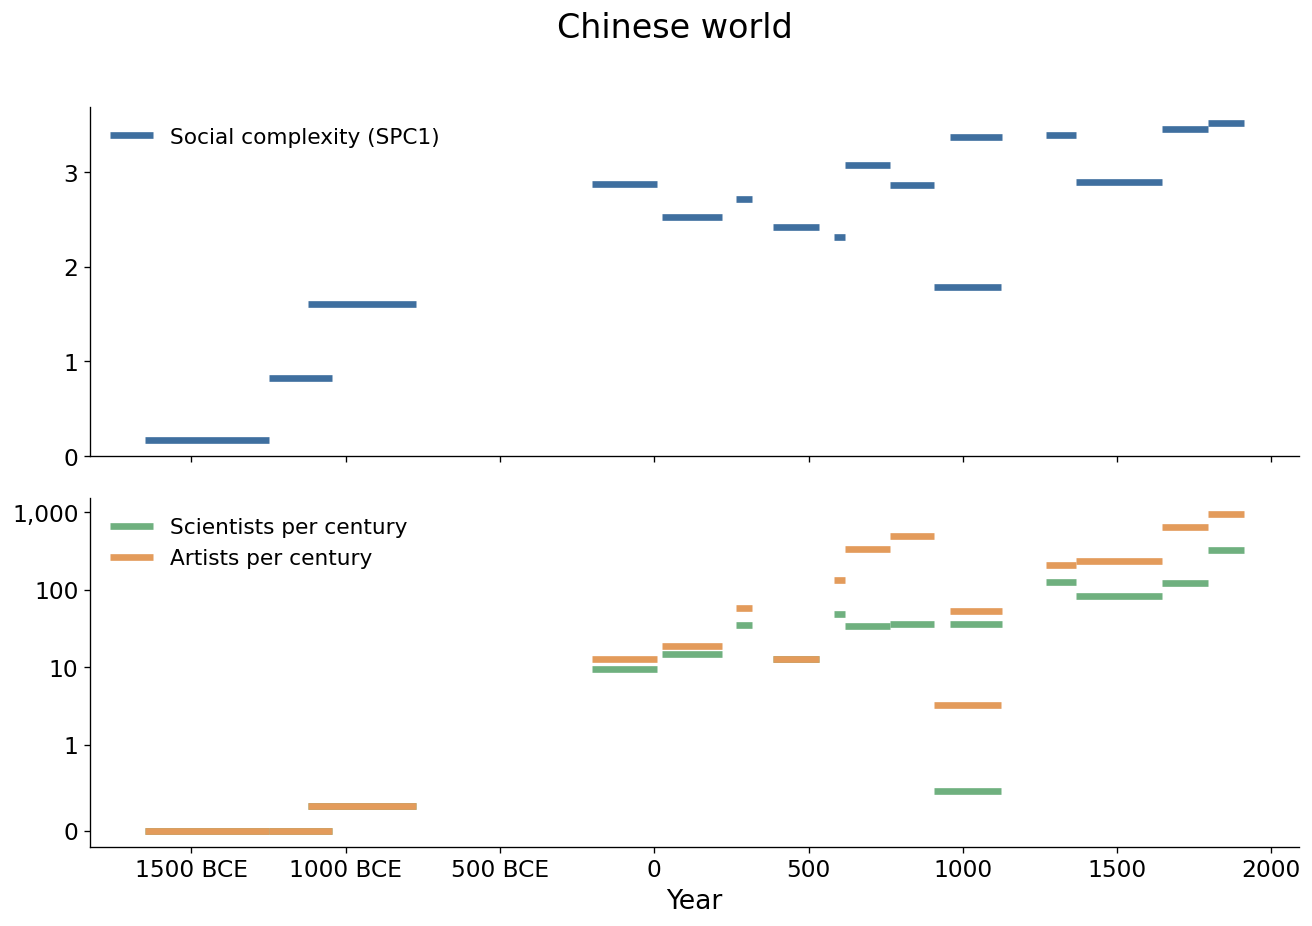

In [13]:
def year_label(year, _position=None):
    return f'{-int(year)} BCE' if year < 0 else f'{int(year)}'


def draw_spans(ax, table, column, color, label):
    for i, row in enumerate(table.iter_rows(named=True)):
        ax.hlines(row[column], row['start_year'], row['end_year'], color=color, lw=4,
                  label=label if i == 0 else None)


fig, (ax_top, ax_bottom) = plt.subplots(2, 1, figsize=(13, 8), sharex=True, gridspec_kw={'hspace': 0.12})
draw_spans(ax_top, world, 'spc1', COLORS['complexity'], 'Social complexity (SPC1)')
draw_spans(ax_bottom, world, 'scientists_per_century', COLORS['scientists'], 'Scientists per century')
draw_spans(ax_bottom, world, 'artists_per_century', COLORS['artists'], 'Artists per century')

ax_bottom.set_yscale('symlog', linthresh=1)
ax_bottom.yaxis.set_major_formatter(THOUSANDS)
ax_bottom.xaxis.set_major_formatter(ticker.FuncFormatter(year_label))
ax_bottom.set_xlabel('Year')
for ax in (ax_top, ax_bottom):
    ax.legend(frameon=False, loc='upper left')
fig.suptitle(WORLD, fontsize=20, color='black')
plt.show()

### Figure 2: Scientists and artists per century against social complexity, Chinese world

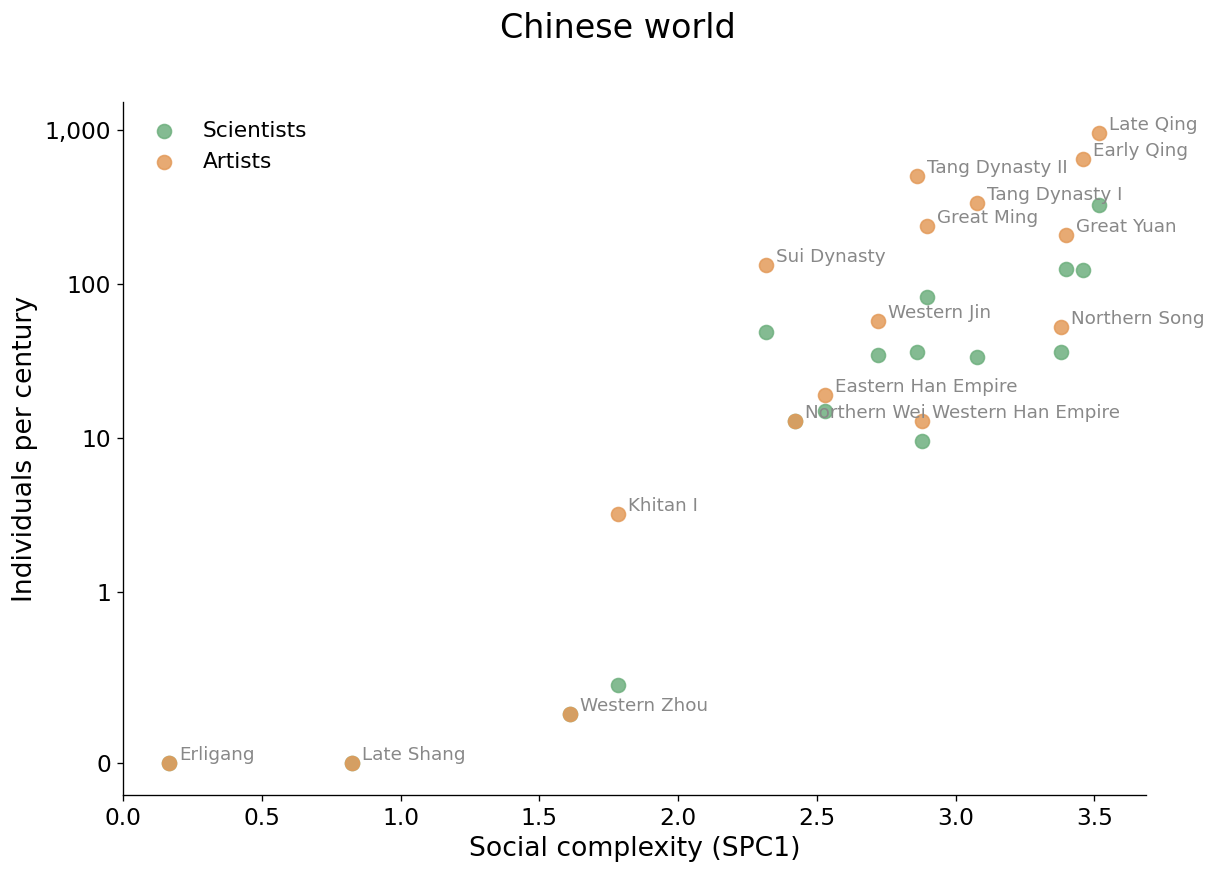

In [14]:
fig, ax = plt.subplots(figsize=(11, 7.5))
for group in ('scientists', 'artists'):
    ax.scatter(world['spc1'], world[f'{group}_per_century'], s=70, color=COLORS[group],
               alpha=0.85, label=group.capitalize())
for row in world.iter_rows(named=True):
    ax.annotate(row['seshat_name'], (row['spc1'], row['artists_per_century']),
                fontsize=POINT_LABEL_FONTSIZE, color=COLORS['neutral'], xytext=(6, 2), textcoords='offset points')
ax.set_yscale('symlog', linthresh=1)
ax.yaxis.set_major_formatter(THOUSANDS)
ax.set_xlabel('Social complexity (SPC1)')
ax.set_ylabel('Individuals per century')
ax.legend(frameon=False)
fig.suptitle(WORLD, fontsize=20, color='black')
plt.show()

### Correlation

The correlation is Spearman's ρ between SPC1 and individuals per century. Both quantities rise with time, and Wikidata's coverage also grows with recency, so the **partial** ρ removes the common time trend. It is the Pearson correlation of the ranks of both variables after regressing each on the rank of the polity's mid-year.

In [15]:
def partial_spearman(x, y, control):
    rx, ry, rc = (stats.rankdata(v) for v in (x, y, control))
    residual = lambda r: r - np.polyval(np.polyfit(rc, r, 1), rc)
    return stats.pearsonr(residual(rx), residual(ry))


def correlations(table, name):
    rows = []
    for group in ('scientists', 'artists'):
        y = table[f'{group}_per_century'].to_numpy()
        x, t = table['spc1'].to_numpy(), table['mid_year'].to_numpy()
        rho, p = stats.spearmanr(x, y)
        partial_rho, partial_p = partial_spearman(x, y, t)
        rows.append({'world': name, 'group': group, 'n_polities': table.height,
                     'spearman_rho': round(rho, 2), 'p': float(f'{p:.2g}'),
                     'partial_rho_given_time': round(partial_rho, 2), 'partial_p': float(f'{partial_p:.2g}')})
    return pl.DataFrame(rows)


correlations(world, WORLD)

world,group,n_polities,spearman_rho,p,partial_rho_given_time,partial_p
str,str,i64,f64,f64,f64,f64
"""Chinese world""","""scientists""",16,0.84,0.000052,0.45,0.079
"""Chinese world""","""artists""",16,0.83,0.000058,0.5,0.048


### Reading
- **Ceiling effect**: From the Han onwards, Chinese polities sit near the top of the global SPC1 scale, so within China the index varies little over the last two millennia. Most of its range comes from the Bronze Age polities (Erligang, Shang, Western Zhou).
- **Small sample**: 16 Seshat polities, so p-values are indicative only.
- **Recency bias**: Cultura's counts grow towards the present with Wikidata coverage. The partial correlation removes the linear part of that trend in ranks, not all of it.

## Other cultural worlds

In [16]:
worlds = {name: world_table(name) for name in [WORLD] + OTHER_WORLDS}
summary = pl.concat([correlations(table, name) for name, table in worlds.items() if table.height >= 5])
summary

world,group,n_polities,spearman_rho,p,partial_rho_given_time,partial_p
str,str,i64,f64,f64,f64,f64
"""Chinese world""","""scientists""",16,0.84,0.000052,0.45,0.079
"""Chinese world""","""artists""",16,0.83,0.000058,0.5,0.048
"""Muslim world""","""scientists""",23,0.3,0.17,0.33,0.12
"""Muslim world""","""artists""",23,0.22,0.31,0.21,0.34
"""India""","""scientists""",11,0.25,0.45,0.17,0.61
"""India""","""artists""",11,0.27,0.42,0.12,0.72
"""Japan""","""scientists""",8,0.64,0.086,0.43,0.28
"""Japan""","""artists""",8,0.81,0.015,0.72,0.046
"""Greek world""","""scientists""",7,0.96,0.00045,0.97,0.00033


### Figure 3: Scientists and artists per century against social complexity, by cultural world

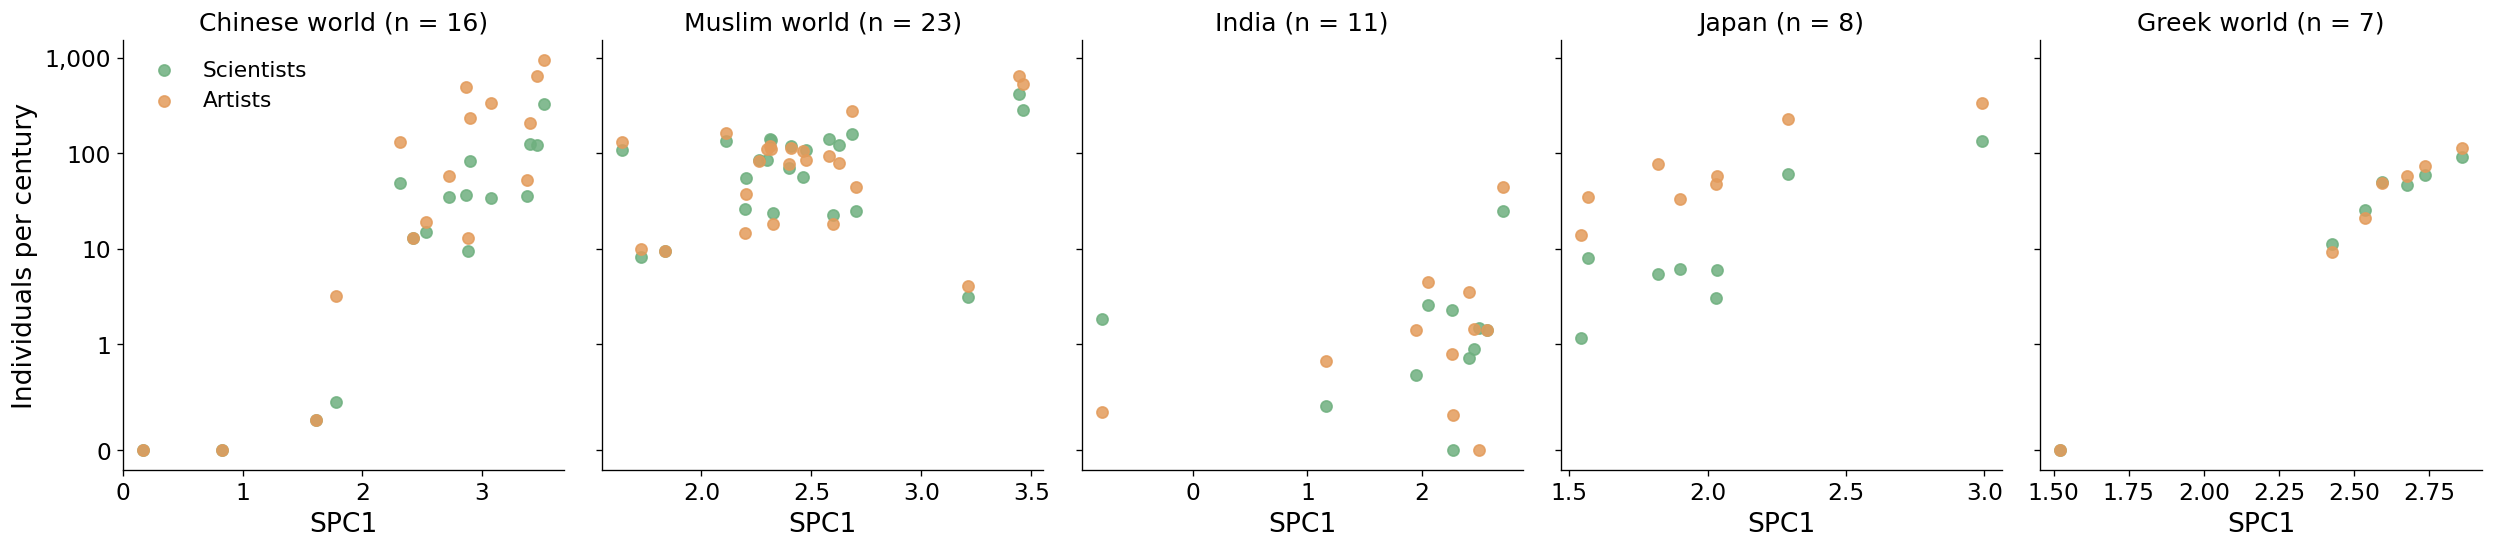

In [17]:
fig, axes = plt.subplots(1, len(worlds), figsize=(4.2 * len(worlds), 4.8), sharey=True)
for ax, (name, table) in zip(axes, worlds.items()):
    for group in ('scientists', 'artists'):
        ax.scatter(table['spc1'], table[f'{group}_per_century'], s=45, color=COLORS[group],
                   alpha=0.85, label=group.capitalize())
    ax.set_yscale('symlog', linthresh=1)
    ax.yaxis.set_major_formatter(THOUSANDS)
    ax.set_title(f'{name} (n = {table.height})', fontsize=15, color='black')
    ax.set_xlabel('SPC1')
axes[0].set_ylabel('Individuals per century')
axes[0].legend(frameon=False, loc='upper left')
plt.tight_layout()
plt.show()